# Assignment 2 — Build the loop
## Agentic AI Workshop I — Incident Triage

This notebook extends Assignment 1's deterministic triage runbook into two LangGraph architectures: a reflex graph with rules-only assessment and a hybrid graph with a local Gemma model in the narrow log-classification step. Both are evaluated on the same 100 alerts as the Week 1 baseline.

## 1. Setup and evaluation contract

The agent can see only tool results. `_truth` is retained in the generated alerts solely for scoring. Each tool call gets one retry; after two timeouts, the graph records a missing value and chooses the cost-safe fallback `escalate`.

In [4]:
import os
import time
from typing import Any, TypedDict
from alertgen import generate_alerts, Tools, score, COST

alerts_100 = generate_alerts(100, seed=0)

try:
    from langgraph.graph import StateGraph, START, END
    from langgraph.checkpoint.memory import MemorySaver
    from langgraph.types import Command
    LANGGRAPH_AVAILABLE = True
except ImportError as exc:
    LANGGRAPH_AVAILABLE = False
    print('Install langgraph to run graph cells:', exc)

MODEL_NAME = 'google/gemma-3-1b-it'
API_MODEL_NAME = os.environ.get('HF_API_MODEL', 'meta-llama/Llama-3.1-8B-Instruct:novita')
HF_API_URL = 'https://router.huggingface.co/v1/chat/completions'
BACKEND = 'api'  # 'api' uses HF_TOKEN; 'local' uses Gemma; fallback is keyword rules
print(f'{len(alerts_100)} alerts loaded; LangGraph available: {LANGGRAPH_AVAILABLE}')
print(f'Configured model backend: {BACKEND}')
print(f'API model: {API_MODEL_NAME}')

100 alerts loaded; LangGraph available: True
Configured model backend: api
API model: meta-llama/Llama-3.1-8B-Instruct:novita


## 2. Shared state, resilient tools, and assessment

The `assess` node classifies log text; it does not select a tool or an action. That split is deliberate: tool selection and side effects belong to the graph's explicit, testable control flow, while the model handles the one task where language understanding is useful.

In [5]:
class TriageState(TypedDict, total=False):
    alert_id: str
    logs: list[str]
    error_rate: dict[str, float] | None
    deploy: dict[str, Any] | None
    log_class: str
    confidence: float
    action: str
    tool_errors: list[str]
    interrupted: bool

def call_with_retry(fn, *args, retries=1, errors=None, **kwargs):
    for attempt in range(retries + 1):
        try:
            return fn(*args, **kwargs)
        except TimeoutError:
            if errors is not None:
                errors.append(f'{fn.__name__} timeout on attempt {attempt + 1}')
    return None

def keyword_assess(logs):
    text = ' '.join(logs).lower()
    if any(x in text for x in ('nullpointer', 'schema mismatch', 'deserialize', 'unhandled exception')):
        return 'bad_deploy', 0.95
    if any(x in text for x in ('connection refused', 'dns resolution', 'tls handshake', 'returned 503')):
        return 'dependency', 0.95
    if any(x in text for x in ('upstream', 'retry budget', 'thread pool', 'circuit breaker')):
        return 'degraded', 0.85
    return 'noise', 0.80

def load_model_backend():
    if BACKEND == 'api':
        token = os.environ.get('HF_TOKEN')
        if not token:
            message = 'HF_TOKEN is not set in the notebook environment.'
            print(f'HUGGING FACE API UNAVAILABLE: {message}')
            print('FALLBACK ACTIVE: using the deterministic keyword classifier; hybrid results are not API results.')
            return None, {'backend': 'keyword_fallback', 'model': API_MODEL_NAME, 'fallback': True, 'error': message}
        print(f'Using Hugging Face Inference API for {API_MODEL_NAME}. Token is read from HF_TOKEN and never displayed.')
        return 'api', {'backend': 'huggingface_api', 'model': API_MODEL_NAME, 'fallback': False, 'error': None}

    print(f'Attempting local Gemma load: {MODEL_NAME}')
    try:
        from transformers import pipeline
        loaded_model = pipeline('text-generation', model=MODEL_NAME, max_new_tokens=12, do_sample=False)
        print(f'LOCAL GEMMA LOADED: {MODEL_NAME}. Hybrid measurements will use local model inference.')
        return loaded_model, {'backend': 'local_gemma', 'model': MODEL_NAME, 'fallback': False, 'error': None}
    except ModuleNotFoundError as exc:
        message = f'Local Gemma could not load because a required package is missing: {exc}'
    except Exception as exc:
        message = f'Local Gemma could not load. This may be a model download, access, device, or memory issue: {type(exc).__name__}: {exc}'
    print(f'LOCAL GEMMA LOAD FAILED: {message}')
    print('FALLBACK ACTIVE: using the deterministic keyword classifier; hybrid results are not Gemma results.')
    return None, {'backend': 'keyword_fallback', 'model': MODEL_NAME, 'fallback': True, 'error': message}

def api_assess(logs):
    import requests
    response = requests.post(
        HF_API_URL,
        headers={'Authorization': f'Bearer {os.environ["HF_TOKEN"]}'},
        json={
            'model': API_MODEL_NAME,
            'messages': [{'role': 'user', 'content':
                'Classify these incident logs as exactly one of noise, degraded, bad_deploy, dependency. '
                'Return only the label.\n' + '\n'.join(logs)}],
            'temperature': 0,
            'max_tokens': 12,
        },
        timeout=60,
    )
    response.raise_for_status()
    raw = response.json()['choices'][0]['message']['content'].lower()
    for label in ('bad_deploy', 'dependency', 'degraded', 'noise'):
        if label in raw:
            return label, 0.90
    return 'noise', 0.30

model_backend, MODEL_STATUS = load_model_backend()
print('Model status:', MODEL_STATUS)

_api_failure_reported = False

def model_assess(logs):
    global _api_failure_reported
    if model_backend == 'api':
        try:
            return api_assess(logs)
        except Exception as exc:
            MODEL_STATUS.update({'backend': 'keyword_fallback', 'fallback': True, 'error': f'{type(exc).__name__}: {exc}'})
            if not _api_failure_reported:
                print(f'HUGGING FACE API REQUEST FAILED: {type(exc).__name__}: {exc}')
                print('FALLBACK ACTIVE: this alert and subsequent alerts use the deterministic keyword classifier; hybrid results are mixed.')
                _api_failure_reported = True
            return keyword_assess(logs)
    if model_backend is None:
        return keyword_assess(logs)
    prompt = ('Classify these incident logs as exactly one of noise, degraded, bad_deploy, dependency. '
              'Return only the label.\n' + '\n'.join(logs))
    raw = model_backend(prompt)[0]['generated_text'].lower()
    for label in ('bad_deploy', 'dependency', 'degraded', 'noise'):
        if label in raw:
            return label, 0.90
    return 'noise', 0.30

def action_from_evidence(state):
    er = state.get('error_rate')
    if er is None or er['current'] / er['baseline_7d'] < 3.0:
        return 'ignore'
    if state.get('log_class') == 'bad_deploy' and state.get('deploy') is not None and state['deploy']['minutes_since_deploy'] <= 25:
        return 'rollback'
    return 'escalate'

Using Hugging Face Inference API for meta-llama/Llama-3.1-8B-Instruct:novita. Token is read from HF_TOKEN and never displayed.
Model status: {'backend': 'huggingface_api', 'model': 'meta-llama/Llama-3.1-8B-Instruct:novita', 'fallback': False, 'error': None}


## 3. Four-node graphs

Every graph has `gather`, `assess`, `decide`, and `act`. The reflex graph uses rules in `assess` and a direct `assess → decide` edge; missing error-rate evidence is handled inside `decide` by falling back to `escalate`. The hybrid graph uses Gemma in `assess` and adds a conditional `assess → recover/decide` edge: missing logs or low-confidence classification takes the recovery path, while confident classifications continue to the explicit decision policy. The graph, rather than the model, owns the action policy.

In [ ]:
def make_graph(tools, assess_fn, hybrid=False, checkpointer=None, interrupt_before_act=False):
    if not LANGGRAPH_AVAILABLE:
        raise RuntimeError('Install langgraph before building the agent.')

    def gather(state):
        errors = list(state.get('tool_errors', []))
        return {
            'logs': call_with_retry(tools.read_logs, state['alert_id'], errors=errors) or [],
            'error_rate': call_with_retry(tools.error_rate, state['alert_id'], errors=errors),
            'deploy': call_with_retry(tools.deploy_history, state['alert_id'], errors=errors),
            'tool_errors': errors,
        }

    def assess(state):
        label, confidence = assess_fn(state.get('logs', []))
        return {'log_class': label, 'confidence': confidence}

    def recover(state):
        return {'log_class': 'unknown', 'confidence': 0.0, 'action': 'escalate'}

    def decide(state):
        if state.get('error_rate') is None:
            return {'action': 'escalate'}
        return {'action': action_from_evidence(state)}

    def act(state):
        return {'interrupted': False}

    def route_after_assess(state):
        if not state.get('logs') or state.get('confidence', 0.0) < 0.75:
            return 'recover'
        return 'decide'

    graph = StateGraph(TriageState)
    graph.add_node('gather', gather)
    graph.add_node('assess', assess)
    graph.add_node('decide', decide)
    graph.add_node('act', act)
    graph.add_edge(START, 'gather')
    graph.add_edge('gather', 'assess')
    if hybrid:
        graph.add_node('recover', recover)
        graph.add_conditional_edges('assess', route_after_assess, {'recover': 'recover', 'decide': 'decide'})
        graph.add_edge('recover', 'act')
    else:
        graph.add_edge('assess', 'decide')
    graph.add_edge('decide', 'act')
    graph.add_edge('act', END)
    compiled = graph.compile(checkpointer=checkpointer, interrupt_before=['act'] if interrupt_before_act else None)
    compiled.tools = tools
    return compiled


def run_graph(agent, alerts, seed=0, flaky=0.10):
    tools = getattr(agent, 'tools', None)
    if tools is None:
        tools = Tools(alerts, seed=seed, flaky=flaky)
    decisions, errors = {}, 0
    started = time.perf_counter()
    for alert in alerts:
        state = agent.invoke(
            {'alert_id': alert['alert_id']},
            config={'configurable': {'thread_id': alert['alert_id']}}
        )
        decisions[alert['alert_id']] = state.get('action', 'escalate')
        errors += len(state.get('tool_errors', []))
    elapsed = time.perf_counter() - started
    return decisions, tools.calls, elapsed, errors


: 

Reflex graph:


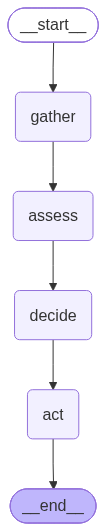

Hybrid graph:


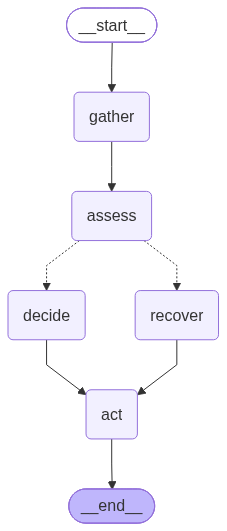

In [7]:
from IPython.display import Image, display

reflex_tools = Tools(alerts_100, seed=0, flaky=0.10)
reflex_agent = make_graph(reflex_tools, keyword_assess, hybrid=False)
hybrid_tools = Tools(alerts_100, seed=0, flaky=0.10)
hybrid_agent = make_graph(hybrid_tools, model_assess, hybrid=True)

print('Reflex graph:')
display(Image(reflex_agent.get_graph().draw_mermaid_png()))
print('Hybrid graph:')
display(Image(hybrid_agent.get_graph().draw_mermaid_png()))

## 4. Measure the four-way comparison

The fourth row is the Week 1 numeric baseline. All rows use the same `alerts_100` and `flaky=0.10`; wall time includes tool calls and model inference when the configured backend is active. With `BACKEND = 'api'`, the hybrid row uses the Hugging Face Inference API and `HF_TOKEN`; with `BACKEND = 'local'`, it uses local Gemma inference.

In [11]:
def baseline_triage(alert_id, tools):
    errors = []
    er = call_with_retry(tools.error_rate, alert_id, errors=errors)
    if er is None:
        return 'escalate'
    if er['current'] / er['baseline_7d'] < 3.0:
        return 'ignore'
    dh = call_with_retry(tools.deploy_history, alert_id, errors=errors)
    return 'rollback' if dh is not None and dh['minutes_since_deploy'] <= 25 else 'escalate'


def measure_baseline():
    tools = Tools(alerts_100, seed=0, flaky=0.10)
    start = time.perf_counter()
    decisions = {a['alert_id']: baseline_triage(a['alert_id'], tools) for a in alerts_100}
    return decisions, tools.calls, time.perf_counter() - start


def measure_reference():
    start = time.perf_counter()
    decisions = {a['alert_id']: 'escalate' for a in alerts_100}
    return decisions, 0, time.perf_counter() - start


baseline_decisions, baseline_calls, baseline_time = measure_baseline()
reflex_tools = Tools(alerts_100, seed=0, flaky=0.10)
reflex_agent = make_graph(reflex_tools, keyword_assess)
hybrid_tools = Tools(alerts_100, seed=0, flaky=0.10)
hybrid_agent = make_graph(hybrid_tools, model_assess, hybrid=True)
reference_decisions, reference_calls, reference_time = measure_reference()

reflex_decisions, reflex_calls, reflex_time, reflex_errors = run_graph(reflex_agent, alerts_100)
hybrid_decisions, hybrid_calls, hybrid_time, hybrid_errors = run_graph(hybrid_agent, alerts_100)

rows = []
for name, decisions, calls, wall, errors in [
    ('Week 1 baseline', baseline_decisions, baseline_calls, baseline_time, None),
    ('Always-escalate reference', reference_decisions, reference_calls, reference_time, None),
    ('Reflex LangGraph', reflex_decisions, reflex_calls, reflex_time, reflex_errors),
    ('Hybrid Gemma LangGraph', hybrid_decisions, hybrid_calls, hybrid_time, hybrid_errors),
]:
    result = score(alerts_100, decisions)
    rows.append({'architecture': name, 'accuracy': result['accuracy'], 'cost_per_alert': result['cost_per_alert'], 'tool_calls': calls, 'wall_time_s': wall, 'timeouts_after_retry': errors})

import pandas as pd
comparison = pd.DataFrame(rows)
display(comparison.style.format({'accuracy': '{:.1%}', 'cost_per_alert': '${:.2f}', 'wall_time_s': '{:.3f}'}))

,architecture,accuracy,cost_per_alert,tool_calls,wall_time_s,timeouts_after_retry
0,Week 1 baseline,68.0%,$77.15,194,0.001,nan
1,Always-escalate reference,41.0%,$61.25,0,0.000,nan
2,Reflex LangGraph,82.0%,$38.65,0,0.225,30.000000
3,Hybrid Gemma LangGraph,77.0%,$52.40,0,58.827,30.000000


## 5. Failure handling

With `flaky=0.10`, each tool timeout is retried once. A second timeout is recorded in `tool_errors`; missing evidence never causes an unsafe model-driven action. The policy falls back to `escalate` when error rate is unavailable and refuses `rollback` when deploy history is unavailable. The comparison table reports these post-retry failures.

In [9]:
demo_tools = Tools(alerts_100, seed=7, flaky=1.0)
demo_agent = make_graph(demo_tools, keyword_assess)
demo = demo_agent.invoke({'alert_id': alerts_100[0]['alert_id']})
print({k: demo.get(k) for k in ('action', 'error_rate', 'deploy', 'tool_errors')})
assert demo['action'] == 'escalate'
print('Fallback verified: complete tool failure produces escalate.')

{'action': 'escalate', 'error_rate': None, 'deploy': None, 'tool_errors': ['read_logs timeout on attempt 1', 'read_logs timeout on attempt 2', 'error_rate timeout on attempt 1', 'error_rate timeout on attempt 2', 'deploy_history timeout on attempt 1', 'deploy_history timeout on attempt 2']}
Fallback verified: complete tool failure produces escalate.


## 6. Persistence: interrupt and resume

`MemorySaver` checkpoints state before `act`. The first invocation pauses after `decide`; the second invocation resumes the same thread and reaches `act`. In production, replace `MemorySaver` with a durable checkpointer.

In [10]:
checkpointer = MemorySaver()
persistent_tools = Tools(alerts_100, seed=0, flaky=0.0)
persistent_agent = make_graph(persistent_tools, keyword_assess, checkpointer=checkpointer, interrupt_before_act=True)
config = {'configurable': {'thread_id': 'resume-demo-0000'}}
paused = persistent_agent.invoke({'alert_id': alerts_100[0]['alert_id']}, config=config)
print('Interrupted state:', {k: paused.get(k) for k in ('alert_id', 'log_class', 'action', 'interrupted')})
resumed = persistent_agent.invoke(None, config=config)
print('Resumed state:', {k: resumed.get(k) for k in ('alert_id', 'log_class', 'action', 'interrupted')})
assert paused['action'] in ('ignore', 'escalate', 'rollback')
assert resumed['action'] == paused['action']
print('Checkpoint resume verified.')

Interrupted state: {'alert_id': 'ALRT-0000', 'log_class': 'bad_deploy', 'action': 'escalate', 'interrupted': None}
Resumed state: {'alert_id': 'ALRT-0000', 'log_class': 'bad_deploy', 'action': 'escalate', 'interrupted': False}
Checkpoint resume verified.


## 7. What I would ship

Fill this paragraph from the measured table after running the notebook: I would ship **[reflex / hybrid / the Week 1 baseline]** because it achieves **[accuracy]** accuracy at **[cost]** per alert with **[tool calls]** tool calls and **[wall time]** seconds per 100-alert batch. The hybrid split is justified only if its log classification improves the cost/accuracy tradeoff enough to pay for local inference. If it loses to the baseline, that is the result to report: the explicit graph and checkpointing add operational structure, but they do not automatically create a better policy.